# Day 3 — Feature Engineering and Model Improvement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/notebooks/03_day3_model_improvement.ipynb)

**ML/AI & GenAI Internship** · Each concept: examples → 5 exercises → quiz → tasks. Some cells take a minute or two.

---

## What this notebook covers

Five concepts, each in the same shape: **📘 Examples → ✏️ 5 exercises → 🧠 Quiz → 🎯 Tasks.**

| # | Concept |
|---|---|
| 1 | Feature engineering |
| 2 | Feature reduction |
| 3 | Overfitting and underfitting |
| 4 | Cross-validation |
| 5 | Hyperparameter tuning |

**The theme of Day 3:** you already have a working model. Now make it better — **and prove that it is better.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

sns.set_theme(style="whitegrid")
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"

# Load and encode once. Every section below uses these.
loans = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
CATEGORICAL = ["person_gender", "person_education", "person_home_ownership",
               "loan_intent", "previous_loan_defaults_on_file"]
encoded = loans.copy()
for column in CATEGORICAL:
    encoded[column] = LabelEncoder().fit_transform(encoded[column])

X = encoded.drop(columns=["loan_status"])
y = encoded["loan_status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Loaded:", encoded.shape, "| train:", X_train.shape, "| test:", X_test.shape)

Loaded: (9997, 14) | train: (7997, 13) | test: (2000, 13)


---

# Concept 1 — Feature engineering

🧠 **Analogy: height, weight, and BMI.**

A doctor could look at "height: 170cm" and "weight: 85kg" separately. But what matters for health risk is the **relationship** between them — and medicine gave that relationship a name: **BMI**.

BMI is not new information. It is `weight / height²`. But it puts the useful pattern **directly in front of** whoever is looking, instead of leaving them to infer it.

For loans, the equivalent is `loan_amount / income`. A ₹5 lakh loan means something completely different to someone earning ₹3 lakh than to someone earning ₹50 lakh. **Neither column alone tells you that. The ratio does, immediately.**

> **Feature engineering usually improves a model more than switching algorithms does.** Beginners spend hours trying Random Forest instead of Logistic Regression. Experienced practitioners spend those hours building better columns.

## 📘 Examples

### Example 1 — ratio features

In [2]:
work = encoded.copy()

# A ratio is often far stronger than either column alone.
work["loan_to_income"] = (work["loan_amnt"] / work["person_income"]).round(4)

# .replace(0, 1) avoids dividing by zero for people with no experience.
work["income_per_year_worked"] = (
    work["person_income"] / work["person_emp_exp"].replace(0, 1)).round(2)

work[["loan_amnt", "person_income", "loan_to_income"]].head()

,loan_amnt,person_income,loan_to_income
0,10800.0,39704.0,0.2720
1,7796.0,36889.0,0.2113
2,20000.0,97163.0,0.2058
3,10000.0,65605.0,0.1524
4,4600.0,37030.0,0.1242


### Example 2 — binning and flag features

In [3]:
# BINNING: turn a continuous column into meaningful groups.
work["age_group"] = pd.cut(work["person_age"], bins=[0, 25, 35, 50, 100],
                           labels=["Under 25", "25-35", "36-50", "Over 50"])

work["credit_band"] = pd.cut(work["credit_score"], bins=[0, 580, 670, 740, 850],
                             labels=["Poor", "Fair", "Good", "Excellent"])

# FLAG: encode domain knowledge as a single 0/1 column.
work["high_interest"] = (work["loan_int_rate"] > 15).astype(int)

# DID IT HELP? Always check the new feature against the target.
print("Approval rate by credit band:")
print(work.groupby("credit_band", observed=True)["loan_status"].mean().round(3))
print("\nApproval rate by age group:")
print(work.groupby("age_group", observed=True)["loan_status"].mean().round(3))

Approval rate by credit band:
credit_band
Poor         0.497
Fair         0.502
Good         0.498
Excellent    0.375
Name: loan_status, dtype: float64

Approval rate by age group:
age_group
Under 25    0.522
25-35       0.482
36-50       0.471
Over 50     0.528
Name: loan_status, dtype: float64


### Example 3 — test the feature properly, before and after

In [4]:
BASE_FEATURES = [c for c in encoded.columns if c != "loan_status"]

def score_with(feature_columns, label):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42),
        work[feature_columns], work["loan_status"],
        cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"{label:<34} {scores.mean():.4f} +/- {scores.std():.4f}")
    return scores.mean()

before = score_with(BASE_FEATURES, "Baseline features")
after = score_with(BASE_FEATURES + ["loan_to_income", "high_interest"],
                   "+ engineered features")
print(f"\nDifference: {after - before:+.4f}")

Baseline features                  0.8922 +/- 0.0044


+ engineered features              0.8927 +/- 0.0028

Difference: +0.0005


**✅ Read that difference honestly.** If it is tiny, the new features did not help much — **and that is a real result worth reporting.**

Features that do not help are not free: they add noise, slow training, and make the model harder to explain.

### Patterns worth trying on almost any dataset

| Pattern | Example |
|---|---|
| Ratio | `loan_amount / income` |
| Difference | `current_year - year_built` → age |
| Binning | age → age group |
| Date parts | date → day of week, month, is_weekend |
| Aggregation | average purchase per customer |
| Flag | `is_first_time_buyer` (0/1) |
| Text length | number of words in a review |

## ✏️ Practice now — Feature engineering

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Create a feature `emp_ratio = person_emp_exp / person_age`. What does it represent?

**2.** Create a flag `low_credit` that is 1 when `credit_score < 600`, else 0. How many rows have it?

**3.** Bin `person_income` into four labelled groups using `pd.cut`. Print the counts per group.

**4.** Check whether `low_credit` relates to the target: `groupby('low_credit')['loan_status'].mean()`.

**5.** Add your best feature to `BASE_FEATURES`, re-run `score_with`, and report whether it helped.

In [5]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1  Fraction of their life spent working - a proxy for career stability.
work["emp_ratio"] = (work["person_emp_exp"] / work["person_age"]).round(4)
print(work["emp_ratio"].describe().round(3))

# 2
work["low_credit"] = (work["credit_score"] < 600).astype(int)
print("rows flagged:", work["low_credit"].sum())

# 3
work["income_band"] = pd.cut(work["person_income"], bins=4,
                             labels=["Low", "Lower-mid", "Upper-mid", "High"])
print(work["income_band"].value_counts().sort_index())

# 4
print(work.groupby("low_credit")["loan_status"].mean().round(3))

# 5
score_with(BASE_FEATURES + ["emp_ratio", "low_credit"], "+ my features")
```

</details>

## 🧠 Quick quiz — Feature engineering

Answer all five from memory. No scrolling back.

**Q1.** Why is `loan_amount / income` more useful than either column alone?

**Q2.** You add a new feature and the cross-validation score drops slightly. What do you do?

**Q3.** What is binning, and when is it useful?

**Q4.** Why does `.replace(0, 1)` appear in the `income_per_year_worked` calculation?

**Q5.** Your team has two hours. Would you spend it trying a new algorithm or engineering features?

<details>
<summary><b>Answers</b></summary>

**A1.** It captures **affordability**. A ₹5 lakh loan is trivial for someone earning ₹50 lakh and impossible for someone earning ₹3 lakh — and neither the loan column nor the income column tells you that on its own.

**A2.** Remove it, and **record the result**. A feature that does not help is not neutral — it adds noise, slows training and makes the model harder to explain. A negative result is still a result and belongs in your report.

**A3.** Converting a continuous column into labelled groups (age → 'Under 25', '25-35'…). It helps when the relationship is not smooth — for example if risk jumps sharply at a threshold rather than rising gradually.

**A4.** To avoid dividing by zero for people with no employment experience. Division by zero produces `inf`, which then breaks the model with an unhelpful error much later in the pipeline.

**A5.** **Features, almost always.** Feature engineering typically improves a model more than switching algorithms does, because it gives the model information it did not previously have — whereas a new algorithm just rearranges the same information.

</details>

## 🎯 Tasks — Feature engineering

Longer work. Do these after the session, in your own time.

### Task 1: Invent, justify and test five features

For the loan dataset, invent **five** new columns. For each, record:

```text
NAME    : ______________________
FORMULA : ______________________
WHY (one plain sentence): __________________
CV BEFORE: ______   CV AFTER: ______   HELPED? ___
```

Test each one **separately** so you know which did what. Keep the ones that failed in your table.

<details><summary>Some good starting points</summary>

| Name | Formula | Why |
|---|---|---|
| `monthly_repayment_burden` | `(loan_amnt × int_rate) / (income / 12)` | How much of a month's pay the interest eats |
| `credit_per_year` | `credit_score / cb_person_cred_hist_length` | Separates a score built slowly from one built recently |
| `started_working_age` | `person_age - person_emp_exp` | Working since 16 is a different profile from a recent graduate |
| `high_risk_combo` | `(defaults == 'Yes') & (credit_score < 600)` | Two red flags together are worse than either alone |
</details>

### Task 2: Feature engineering on a different dataset

Take `classification/heart_failure_raw.csv` and engineer three medically sensible features.

You will need to read what the columns mean — that is the point. **Feature engineering requires domain knowledge, not just Python.**

Report the before/after cross-validation scores, and write one sentence on which feature helped most and why you think it did.

---

# Concept 2 — Feature reduction

Too many features cause slow training, overfitting, and models nobody can explain.

| Method | Keeps column names? | Use when |
|---|---|---|
| **Feature importance** | ✅ Yes | You must explain the model to a person |
| **SelectKBest** | ✅ Yes | You want a quick statistical filter |
| **PCA** | ❌ **No** | Many correlated columns, and interpretability does not matter |

## 📘 Examples

### Example 1 — feature importance, the most interpretable method

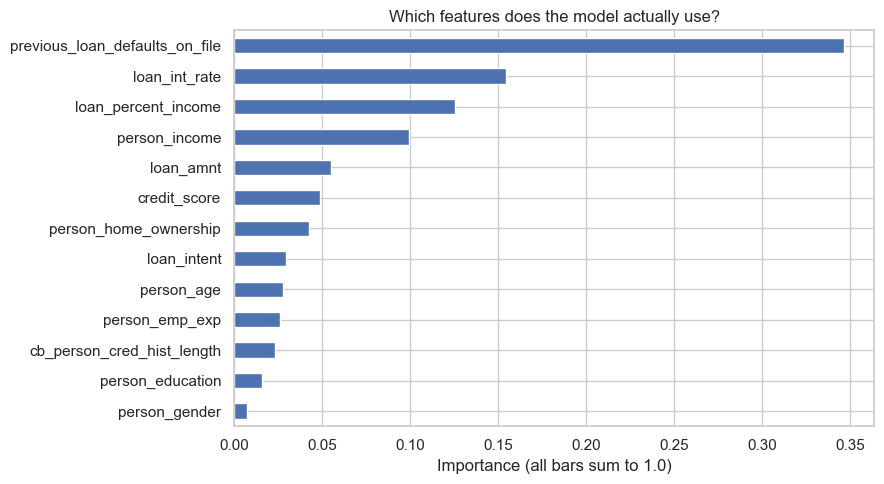

previous_loan_defaults_on_file    0.3461
loan_int_rate                     0.1543
loan_percent_income               0.1252
person_income                     0.0991
loan_amnt                         0.0548
credit_score                      0.0485
person_home_ownership             0.0424
loan_intent                       0.0296
person_age                        0.0277
person_emp_exp                    0.0258
cb_person_cred_hist_length        0.0233
person_education                  0.0158
person_gender                     0.0074
dtype: float64


In [6]:
forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)

importances = (pd.Series(forest.feature_importances_, index=X.columns)
                 .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind="barh")
plt.title("Which features does the model actually use?")
plt.xlabel("Importance (all bars sum to 1.0)")
plt.tight_layout()
plt.show()

print(importances.round(4))

### 📊 How to read this chart — Feature importance chart

| What you are looking at | What it means |
|---|---|
| **Bar length** | How much this feature contributed to the model's decisions |
| **All bars together** | Always sum to 1.0 — these are *shares*, not scores |
| **The top bar** | The feature the model relies on most |
| **Bars near zero** | Features the model barely uses. Candidates for removal |
| **One bar dominating everything** | ⚠️ Check for leakage — is that column secretly the answer? |
| **All bars roughly equal** | No single feature dominates; the signal is spread out |

> **In one sentence:** Read the top three bars to know what your model is actually doing — and if one bar towers over everything, check that column is not leaking the target.

> ⚠️ **Feature importance is *global*, not personal.** It tells you what mattered across all 10,000 rows, not what drove one particular prediction. Explaining a single decision needs a different tool (SHAP, or the manual approach in the tasks below).

### Example 2 — SelectKBest, a quick statistical filter

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X_train, y_train)

kept = list(X.columns[selector.get_support()])
dropped = [c for c in X.columns if c not in kept]

print("SelectKBest kept these 6:")
for c in kept: print("  ✅", c)
print("\nAnd dropped:")
for c in dropped: print("  ❌", c)

SelectKBest kept these 6:
  ✅ person_income
  ✅ person_home_ownership
  ✅ loan_amnt
  ✅ loan_int_rate
  ✅ loan_percent_income
  ✅ previous_loan_defaults_on_file

And dropped:
  ❌ person_age
  ❌ person_gender
  ❌ person_education
  ❌ person_emp_exp
  ❌ loan_intent
  ❌ cb_person_cred_hist_length
  ❌ credit_score


### Example 3 — PCA, and what you give up

Original columns: 13  ->  components: 10
Variance explained by each: [0.221 0.145 0.117 0.084 0.078 0.077 0.075 0.072 0.055 0.049]


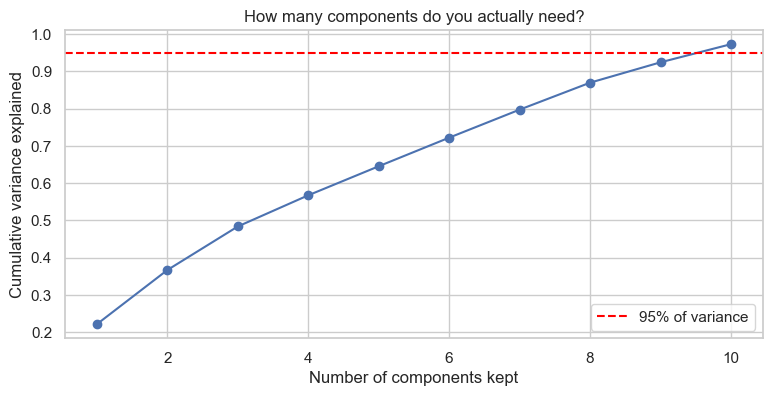

In [8]:
from sklearn.decomposition import PCA

# PCA needs SCALED data, and the components are NOT human-readable.
X_train_scaled = StandardScaler().fit_transform(X_train)

pca = PCA(n_components=0.95)          # keep enough components for 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"Original columns: {X_train.shape[1]}  ->  components: {X_train_pca.shape[1]}")
print("Variance explained by each:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% of variance")
plt.xlabel("Number of components kept")
plt.ylabel("Cumulative variance explained")
plt.title("How many components do you actually need?")
plt.legend()
plt.show()

### 📊 How to read this chart — PCA cumulative variance curve

| What you are looking at | What it means |
|---|---|
| **The x-axis** | How many components you keep |
| **The y-axis** | What fraction of the original information they preserve |
| **The red dashed line** | Your target — here 95% of the variance |
| **Where the curve crosses the line** | The number of components you need. Read it off the x-axis |
| **A curve that rises steeply then flattens** | A few components carry most of the information — PCA will help a lot |
| **A curve that rises in a near-straight line** | Every component matters roughly equally — PCA will not help much |

> **In one sentence:** Find where the curve crosses your target line: that x-value is how many columns you can compress down to without losing what matters.

> ⚠️ **The price of PCA:** "component 1" has no meaning you can explain to a manager. If you must justify a decision to a person — a loan, a diagnosis, a grade — **do not use PCA.**

## ✏️ Practice now — Feature reduction

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Print the **top 3** most important features from `importances`. Do they match your intuition?

**2.** Print the **bottom 3**. What fraction of total importance do they carry between them?

**3.** Retrain the Random Forest using only the top 6 features. Did the test score drop?

**4.** Run `SelectKBest` with `k=4`. Which four does it keep? Does it agree with feature importance?

**5.** Run PCA keeping 80% of variance instead of 95%. How many components now?

In [9]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1
print(importances.head(3))

# 2
print(importances.tail(3))
print("their combined share:", round(importances.tail(3).sum(), 4))

# 3
top6 = importances.head(6).index.tolist()
m6 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
m6.fit(X_train[top6], y_train)
print("all features:", round(forest.score(X_test, y_test), 4),
      "| top 6 only:", round(m6.score(X_test[top6], y_test), 4))

# 4
s4 = SelectKBest(score_func=f_classif, k=4).fit(X_train, y_train)
print(list(X.columns[s4.get_support()]))

# 5
p80 = PCA(n_components=0.80).fit(X_train_scaled)
print("components for 80%:", p80.n_components_)
```

</details>

## 🧠 Quick quiz — Feature reduction

Answer all five from memory. No scrolling back.

**Q1.** One feature has an importance of 0.85 while all others are below 0.02. What should you check first?

**Q2.** Why can you not use PCA when you must explain a loan rejection to an applicant?

**Q3.** Feature importances always sum to 1.0. What does that mean for interpreting them?

**Q4.** You cut from 13 features to 6 and the score stays the same. Is that a good outcome?

**Q5.** What is the difference between feature importance being *global* and an explanation being *personal*?

<details>
<summary><b>Answers</b></summary>

**A1.** **Data leakage.** A single feature dominating that heavily often means it is derived from the target, or is only available *after* the outcome is known. Check what that column actually is and when it becomes available.

**A2.** PCA's components are mathematical combinations of the original columns. 'Component 3 was low' is not an explanation any person can act on, and in several jurisdictions applicants have a legal right to a meaningful explanation.

**A3.** They are **shares of the total**, not absolute scores. An importance of 0.3 means that feature accounted for 30% of the model's decision-making, relative to the others in this particular model.

**A4.** Yes, usually. You get a simpler, faster model that is easier to explain and less likely to overfit, at no cost in accuracy. Fewer columns also means fewer things to collect and validate in production.

**A5.** Global importance says what mattered across the whole dataset. A personal explanation says what drove *this one prediction*. A feature can be globally unimportant yet decisive for one unusual applicant.

</details>

## 🎯 Tasks — Feature reduction

Longer work. Do these after the session, in your own time.

### Task 1: The reduction trade-off study

On a dataset with 10 or more numeric columns:

1. Train a model on **all** features. Record score **and fit time**
2. Apply PCA keeping 95% of variance. Retrain. Record both
3. Apply PCA keeping 80%. Retrain. Record both
4. Use feature importance to keep the top half. Retrain. Record both
5. Build a table: method, number of columns, score, fit time, **can you explain it?**
6. **Recommend one approach and defend it in three sentences**

### Task 2: Build a personal explanation

Global importance says what matters overall. Build something that explains **one** prediction.

For a single applicant:
1. Get the model's predicted probability
2. For each feature in turn, replace that feature's value with the dataset **average** and re-predict
3. Record how much the probability moved
4. Rank the features by that movement

That ranking is a simple personal explanation — it is roughly what SHAP does properly.

**Compare it with global feature importance for the same applicant. Do they agree?**

---

# Concept 3 — Overfitting and underfitting

This is the central problem of Machine Learning. If you understand one idea from Day 3, make it this one.

🧠 **Analogy: three students and an exam.**

**Anmol barely studies.** He glances at the practice paper for ten minutes. He does badly on the practice paper *and* badly on the real exam. → **Underfitting.** Too simple; never learned the pattern.

**Bina studies properly.** She works out *why* each answer is right, so she understands the topics. She scores well on both. → **Good fit.**

**Chandra memorises the answer sheet.** Question 4 is "C". Question 5 is "B". He scores 100% on the practice paper — better than Bina. Then the real exam has different questions and he is lost. → **Overfitting.**

> **On the practice paper, Chandra looked like the best student in the room.** That is exactly why you must never judge a model by its training score.

## 📘 Examples

### Example 1 — watch overfitting happen

In [10]:
print(f"{'max_depth':>10} {'train':>8} {'test':>8} {'gap':>8}   which student?")
print("-" * 60)

depths = [1, 2, 3, 5, 10, 20, None]
train_scores, test_scores = [], []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    tr, te = tree.score(X_train, y_train), tree.score(X_test, y_test)
    train_scores.append(tr); test_scores.append(te)

    gap = tr - te
    who = ("Anmol   (underfitting)" if tr < 0.80
           else "Chandra (overfitting)" if gap > 0.05
           else "Bina    (good fit)")
    print(f"{str(depth):>10} {tr:>8.4f} {te:>8.4f} {gap:>8.4f}   {who}")

 max_depth    train     test      gap   which student?
------------------------------------------------------------
         1   0.8286   0.8240   0.0046   Bina    (good fit)
         2   0.8286   0.8240   0.0046   Bina    (good fit)
         3   0.8327   0.8070   0.0257   Bina    (good fit)
         5   0.8803   0.8515   0.0288   Bina    (good fit)
        10   0.9198   0.8690   0.0508   Chandra (overfitting)
        20   0.9961   0.8480   0.1481   Chandra (overfitting)
      None   1.0000   0.8435   0.1565   Chandra (overfitting)


### Example 2 — the same information as a picture

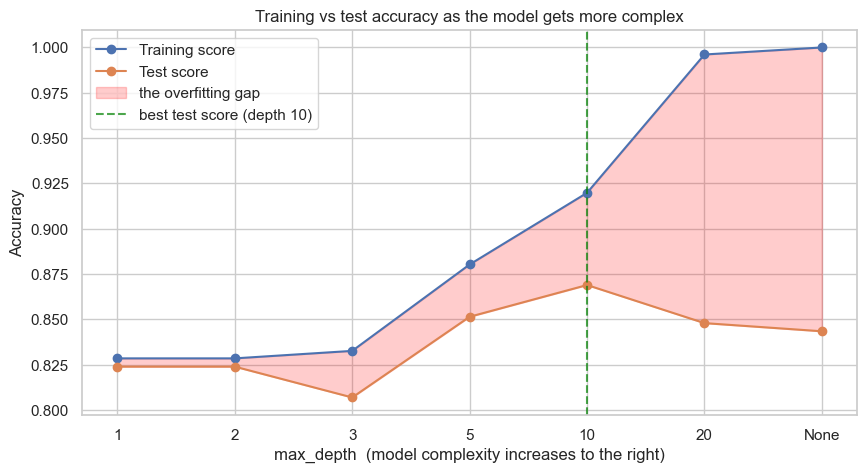

In [11]:
labels = [str(d) if d else "None" for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(labels, train_scores, marker="o", label="Training score")
plt.plot(labels, test_scores, marker="o", label="Test score")
plt.fill_between(range(len(labels)), train_scores, test_scores,
                 alpha=0.2, color="red", label="the overfitting gap")
best = int(np.argmax(test_scores))
plt.axvline(best, color="green", linestyle="--", alpha=0.7,
            label=f"best test score (depth {labels[best]})")
plt.xlabel("max_depth  (model complexity increases to the right)")
plt.ylabel("Accuracy")
plt.title("Training vs test accuracy as the model gets more complex")
plt.legend()
plt.show()

### 📊 How to read this chart — Train vs test curve

| What you are looking at | What it means |
|---|---|
| **The blue line (training)** | How well the model does on data it has already seen |
| **The orange line (test)** | How well it does on data it has **never** seen. This is the one that matters |
| **The left end — both low** | **Underfitting.** The model is too simple to capture the pattern |
| **The red shaded gap** | How much the model memorised rather than learned |
| **Where the orange line peaks** | **Your answer.** The best complexity for this problem |
| **The right end — blue climbs, orange falls** | **Overfitting.** Memorising the training rows, including their noise |
| **Blue and orange close together** | The model generalises well — this is what you want |

> **In one sentence:** Pick the x-value where the **orange** line is highest, never where the blue line is highest — the blue line always improves with complexity and will lead you astray every time.

### Example 3 — regularisation: limiting the model on purpose

In [12]:
# An unlimited tree, then the same tree with one restriction:
# every leaf must cover at least 50 rows, so it cannot carve out a
# branch for a single memorised row.

plain = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train, y_train)
regularised = DecisionTreeClassifier(max_depth=None, min_samples_leaf=50,
                                     random_state=42).fit(X_train, y_train)

for name, m in [("No limits", plain), ("min_samples_leaf=50", regularised)]:
    tr, te = m.score(X_train, y_train), m.score(X_test, y_test)
    print(f"{name:<22} train={tr:.4f}  test={te:.4f}  gap={tr - te:.4f}")

print("\nThe gap shrank AND the test score improved.")
print("You just applied REGULARISATION: deliberately limiting the model's")
print("freedom so it generalises better.")

No limits              train=1.0000  test=0.8435  gap=0.1565
min_samples_leaf=50    train=0.8968  test=0.8715  gap=0.0253

The gap shrank AND the test score improved.
You just applied REGULARISATION: deliberately limiting the model's
freedom so it generalises better.


## ✏️ Practice now — Overfitting

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Train a `DecisionTreeClassifier` with `max_depth=1`. Report train and test scores. Which student is it?

**2.** Train one with `max_depth=None`. Report both scores and the gap.

**3.** Find the `max_depth` between 1 and 15 that gives the **best test score**.

**4.** Take the unlimited tree and add `min_samples_leaf=100`. What happens to the gap?

**5.** Train a `RandomForestClassifier` with default settings. Is its gap smaller or larger than the single tree's?

In [13]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1
m = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)
print("depth 1 :", round(m.score(X_train, y_train), 4), round(m.score(X_test, y_test), 4))
# Both low -> Anmol, underfitting.

# 2
m = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train, y_train)
tr, te = m.score(X_train, y_train), m.score(X_test, y_test)
print("unlimited:", round(tr, 4), round(te, 4), "gap", round(tr - te, 4))

# 3
best = max(range(1, 16),
           key=lambda d: DecisionTreeClassifier(max_depth=d, random_state=42)
                          .fit(X_train, y_train).score(X_test, y_test))
print("best depth:", best)

# 4
m = DecisionTreeClassifier(max_depth=None, min_samples_leaf=100,
                           random_state=42).fit(X_train, y_train)
print("regularised gap:", round(m.score(X_train, y_train) - m.score(X_test, y_test), 4))

# 5
rf = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train)
print("forest gap:", round(rf.score(X_train, y_train) - rf.score(X_test, y_test), 4))
# A forest averages many trees, so it overfits LESS than any single tree.
```

</details>

## 🧠 Quick quiz — Overfitting

Answer all five from memory. No scrolling back.

**Q1.** Training accuracy 0.99, test accuracy 0.71. Diagnose it and give two fixes.

**Q2.** Training accuracy 0.62, test accuracy 0.61. What is happening?

**Q3.** Why should you never choose a model by its training score?

**Q4.** What does `min_samples_leaf=50` actually do, and why does it help?

**Q5.** Why does a Random Forest usually overfit less than a single decision tree?

<details>
<summary><b>Answers</b></summary>

**A1.** **Overfitting** — the model memorised the training rows including their noise. Fixes: reduce complexity (`max_depth`, `min_samples_leaf`), get more data, remove features, add regularisation, or use an ensemble like Random Forest.

**A2.** **Underfitting.** Both scores are low and close together, so the model is too simple to capture the pattern. Add features, use a more flexible model, or train longer — do *not* add regularisation, which would make it worse.

**A3.** Because the training score always improves as the model gets more complex, right up to memorising every row. Chandra scored 100% on the practice paper and failed the exam. **The test score is the only one that predicts real performance.**

**A4.** It forces every leaf of the tree to cover at least 50 rows, so the tree cannot create a branch for one unusual row. That is **regularisation** — deliberately restricting the model so it learns general patterns rather than memorising individuals.

**A5.** It averages many trees, each trained on a different random subset of rows and columns. Individual trees memorise different noise, and averaging cancels much of it out — leaving the pattern they agree on.

</details>

## 🎯 Tasks — Overfitting

Longer work. Do these after the session, in your own time.

### Task 1: The complexity curve, four models

Produce a train-vs-test curve like the one above for **four** different models, each with its own complexity knob:

| Model | Knob to vary |
|---|---|
| `DecisionTreeClassifier` | `max_depth` |
| `RandomForestClassifier` | `max_depth` |
| `KNeighborsClassifier` | `n_neighbors` (note: **lower** k = more complex) |
| `LogisticRegression` | `C` (note: **higher** C = more complex) |

For each: plot both curves, mark the best test score, and write one sentence on where overfitting begins.

Then answer: **which model overfits most readily, and why do you think that is?**

### Task 2: Overfitting on purpose

Make a model overfit as badly as you can, deliberately.

1. Take only **50 rows** of the loan data
2. Train an unlimited decision tree
3. Report train and test scores

Then fix it, one change at a time, recording the gap after each:
- add `max_depth`
- add `min_samples_leaf`
- use more training rows

**Which single change helped most?** Write two sentences on why more data is such a powerful fix.

---

# Concept 4 — Cross-validation

🧠 **Analogy: one practice exam is not enough.**

You sit one practice exam and score 82%. Are you an 82% student?

Maybe. Or maybe that paper happened to cover the two chapters you knew best. Sit five different practice papers and you might score 82, 71, 79, 68, 80 — an average of 76%, with a spread that tells you how *reliable* your performance actually is.

**A single train/test split is one practice paper.** The score depends on which rows happened to land in the test set.

```text
K-Fold with k=5: split the data into 5 equal parts.

Round 1:  [TEST ][train][train][train][train]  -> score 1
Round 2:  [train][TEST ][train][train][train]  -> score 2
Round 3:  [train][train][TEST ][train][train]  -> score 3
Round 4:  [train][train][train][TEST ][train]  -> score 4
Round 5:  [train][train][train][train][TEST ]  -> score 5

Report the MEAN and the STANDARD DEVIATION of the five.
```

## 📘 Examples

### Example 1 — prove that a single split is unreliable

In [14]:
# Same model, same data, same settings. ONLY the random split changes.

print("Five single train/test splits:")
single = []
for seed in [0, 1, 2, 3, 4]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    score = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tr, y_tr).score(X_te, y_te)
    single.append(score)
    print(f"  random_state={seed}: {score:.4f}")

print(f"\n  Lowest : {min(single):.4f}")
print(f"  Highest: {max(single):.4f}")
print(f"  Spread : {max(single) - min(single):.4f}   <- pure luck, nothing else changed")
print("\nIf you reported only the highest, would that be honest?")

Five single train/test splits:
  random_state=0: 0.8500
  random_state=1: 0.8675
  random_state=2: 0.8525
  random_state=3: 0.8540
  random_state=4: 0.8580

  Lowest : 0.8500
  Highest: 0.8675
  Spread : 0.0175   <- pure luck, nothing else changed

If you reported only the highest, would that be honest?


### Example 2 — the honest answer

In [15]:
# StratifiedKFold keeps the class balance in every fold.
# Always use it for classification.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in {
    "Decision Tree (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=42),
    # Logistic Regression needs SCALED features. A Pipeline fits the scaler
    # INSIDE each fold - the only leak-free way to scale during CV.
    "Logistic Regression": make_pipeline(StandardScaler(),
                                         LogisticRegression(max_iter=2000)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = scores
    print(f"{name}")
    print(f"  folds: {scores.round(4)}")
    print(f"  mean {scores.mean():.4f}   std {scores.std():.4f}\n")

Decision Tree (depth 4)
  folds: [0.8515 0.843  0.8474 0.8634 0.8629]
  mean 0.8537   std 0.0082

Logistic Regression
  folds: [0.8765 0.8685 0.8689 0.8699 0.8764]
  mean 0.8721   std 0.0036



Random Forest
  folds: [0.885  0.89   0.8984 0.8954 0.8984]
  mean 0.8935   std 0.0052



### Example 3 — see the spread, do not just read it

/var/folders/ls/qkb453bd3xl7c7yp9n0rszdh0000gn/T/ipykernel_89523/407472470.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=[n.split(" (")[0] for n in results])


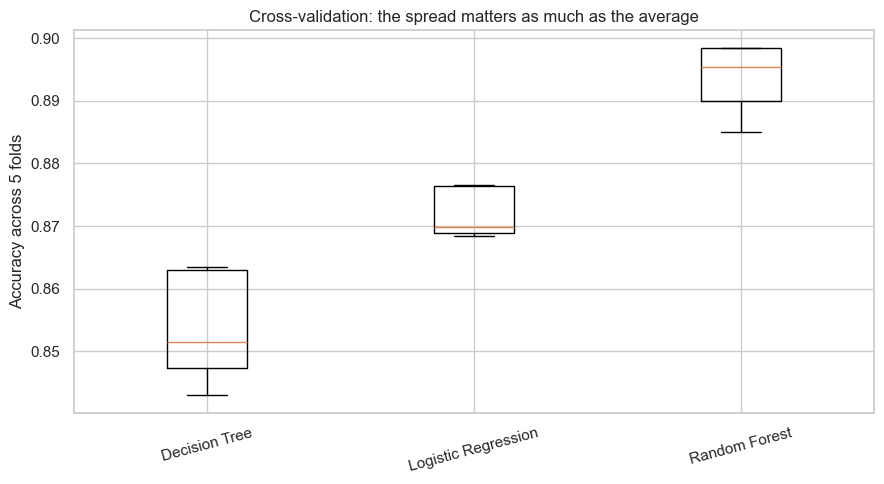

In [16]:
plt.figure(figsize=(9, 5))
plt.boxplot(results.values(), labels=[n.split(" (")[0] for n in results])
plt.ylabel("Accuracy across 5 folds")
plt.title("Cross-validation: the spread matters as much as the average")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 📊 How to read this chart — Cross-validation box plot

| What you are looking at | What it means |
|---|---|
| **The box for each model** | Where its five fold-scores landed |
| **The line inside the box** | The median fold score |
| **A tall box** | ⚠️ Scores vary a lot across folds — **do not trust this model's single score** |
| **A short, flat box** | ✅ Consistent across folds. Dependable |
| **Comparing two models** | If their boxes **overlap heavily**, the difference between them is probably noise |
| **A model with a higher median but a tall box** | It may only look better because of one lucky fold |

> **In one sentence:** A model with a slightly lower mean but a much tighter box is often the better choice — consistency you can rely on beats a high average you cannot reproduce.

**✅ Read the standard deviation, not just the mean.**

- `0.89 ± 0.002` → dependable
- `0.89 ± 0.06` → gives wildly different results depending on the data it sees. Do not trust it.

> ⚠️ **If a classmate's score is suddenly much higher than everyone else's on the same dataset**, the first question is not "what model did you use?" It is **"did you cross-validate, or did you get a lucky split?"**

## ✏️ Practice now — Cross-validation

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Run 5-fold cross-validation on a `RandomForestClassifier`. Report mean and std.

**2.** Run it again with `n_splits=10`. Did the mean change? Did the std?

**3.** Compare `KFold` with `StratifiedKFold` on this data. Why is stratified better here?

**4.** Cross-validate using `scoring="recall"` instead of accuracy. Is the ranking of models the same?

**5.** Run the same model with 5 different `random_state` values in `train_test_split` and compare that spread with the CV std.

In [17]:
from sklearn.model_selection import KFold

# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
from sklearn.model_selection import KFold

# 1
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
s = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                    X, y, cv=cv5, n_jobs=-1)
print("5-fold:", s.mean().round(4), "+/-", s.std().round(4))

# 2
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
s10 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                      X, y, cv=cv10, n_jobs=-1)
print("10-fold:", s10.mean().round(4), "+/-", s10.std().round(4))
# More folds -> more training data per fold -> usually a slightly higher mean,
# but each test fold is smaller, so the std often rises.

# 3  Stratified keeps the class balance in every fold. With plain KFold a fold
#    could get an unrepresentative mix, adding noise that is not about the model.

# 4
sr = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                     X, y, cv=cv5, scoring="recall", n_jobs=-1)
print("recall:", sr.mean().round(4))

# 5 - see Example 1 above: the single-split spread is usually WIDER than the CV std.
```

</details>

## 🧠 Quick quiz — Cross-validation

Answer all five from memory. No scrolling back.

**Q1.** Why is 5-fold cross-validation more trustworthy than a single train/test split?

**Q2.** What does `StratifiedKFold` do that plain `KFold` does not, and when do you need it?

**Q3.** Model A: 0.89 ± 0.002. Model B: 0.91 ± 0.06. Which would you ship?

**Q4.** Why must a scaler go inside a `Pipeline` when cross-validating?

**Q5.** Your classmate reports 96% while everyone else gets 89% on the same data. What is your first question?

<details>
<summary><b>Answers</b></summary>

**A1.** A single split gives one score that depends on which rows happened to land in the test set. Cross-validation trains and tests five times on different splits and averages, so luck is averaged out — and the spread tells you how reliable the number is.

**A2.** It keeps the same class proportions in every fold. You need it for classification — especially with imbalanced classes, where a plain fold could end up with almost none of the minority class.

**A3.** Probably **A**. B's higher mean sits inside a very wide spread, so on new data it might score 0.85 or 0.97. A is only slightly lower but you can predict what you will get, and predictability matters in production.

**A4.** So it is fitted separately on each fold's training portion. Scaling the whole dataset first would leak information from each fold's test portion into training — the same data-leakage error, just hidden inside the CV loop.

**A5.** **"Did you cross-validate, or did you get a lucky split?"** — followed by checking for data leakage. An outlier result on identical data is almost always one of those two, not a genuinely better model.

</details>

## 🎯 Tasks — Cross-validation

Longer work. Do these after the session, in your own time.

### Task 1: The reliability report

For **five** different models on one dataset:

1. Run 5-fold cross-validation, recording each model's fold scores
2. Build a table: model, mean, std, min fold, max fold
3. Draw the box plot
4. Identify any pair of models whose boxes **overlap heavily** — and explain why you cannot claim one beats the other
5. Recommend one model, using **both** the mean and the std in your reasoning

### Task 2: When does cross-validation lie to you?

Cross-validation is not magic. Investigate one case where it gives an over-optimistic answer.

1. Add a leaked feature to the loan dataset — for example a column computed directly from `loan_status`
2. Run cross-validation. What score do you get?
3. Explain why cross-validation did **not** protect you

Then write three sentences on what cross-validation does and does not defend against.

> **The lesson:** cross-validation protects against a lucky split. It does **not** protect against leakage, because the leak is present in every fold.

---

# Concept 5 — Hyperparameter tuning

🧠 **Analogy: the oven dials.**

A cake recipe has two kinds of number.

**Things the cake works out for itself:** how brown the crust gets, how far it rises. You do not set those — they emerge from baking. Those are **parameters**, and the model learns them during `fit()`.

**Things you set before it goes in:** oven temperature 180°C, time 40 minutes, shelf position middle. Those are **hyperparameters**, and no amount of baking will choose them for you.

If the cake comes out burnt on top and raw inside, you do not blame the flour. **You change the dials and bake another one.**

| | What it does | Speed |
|---|---|---|
| **GridSearchCV** | Tries **every** combination | Thorough, slow |
| **RandomizedSearchCV** | Tries **N random** combinations | Much faster, usually nearly as good |

## 📘 Examples

### Example 1 — GridSearchCV

In [18]:
# 3 x 3 x 2 = 18 combinations, each cross-validated 3 times = 54 model fits.
# Keep grids SMALL. This is why it takes a minute or two.

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,          # use all CPU cores
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", round(grid.best_score_, 4))
print("Test score     :", round(grid.score(X_test, y_test), 4))

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score  : 0.8915
Test score     : 0.891


### Example 2 — RandomizedSearchCV, far fewer fits

In [19]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions={
        "n_estimators": [100, 200, 300, 400, 500],
        "max_depth": [5, 10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    n_iter=10,          # only 10 random combinations out of 225 possible
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV score  :", round(random_search.best_score_, 4))
print("Test score     :", round(random_search.score(X_test, y_test), 4))

print(f"\n{'Method':<22}{'CV score':>10}{'model fits':>12}")
print("-" * 44)
print(f"{'GridSearchCV':<22}{grid.best_score_:>10.4f}{18 * 3:>12}")
print(f"{'RandomizedSearchCV':<22}{random_search.best_score_:>10.4f}{10 * 3:>12}")
print("\nWas the grid's extra work worth it?")

Best parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV score  : 0.891
Test score     : 0.89

Method                  CV score  model fits
--------------------------------------------
GridSearchCV              0.8915          54
RandomizedSearchCV        0.8910          30

Was the grid's extra work worth it?


### Example 3 — see what the search actually explored

Top 5 combinations:
param_max_depth  param_n_estimators  param_min_samples_split  mean_test_score  std_test_score
             10                 100                        2         0.891458        0.006627
           None                 200                        2         0.891083        0.005292
           None                 200                        5         0.890958        0.003898
           None                 300                        5         0.890833        0.005118
           None                 100                        2         0.890708        0.004981

Worst 3:
param_max_depth  param_n_estimators  param_min_samples_split  mean_test_score  std_test_score
              5                 100                        5         0.879579        0.004533
              5                 200                        2         0.878579        0.004135
              5                 100                        2         0.878329        0.003676


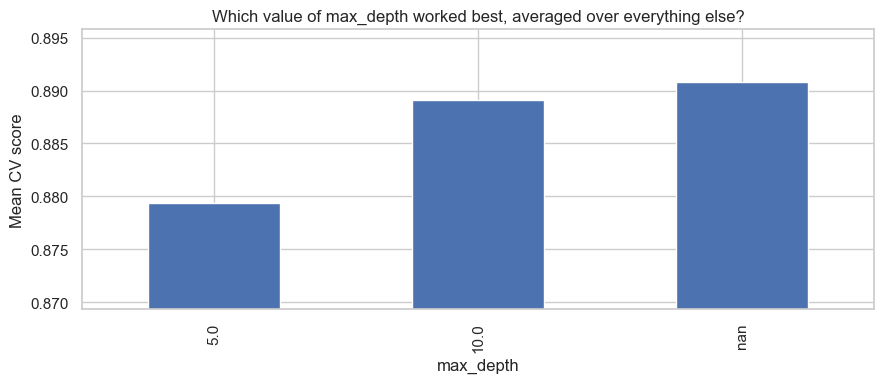

In [20]:
cv_results = pd.DataFrame(grid.cv_results_)

summary = (cv_results[["param_max_depth", "param_n_estimators",
                       "param_min_samples_split", "mean_test_score", "std_test_score"]]
           .sort_values("mean_test_score", ascending=False))

print("Top 5 combinations:")
print(summary.head(5).to_string(index=False))
print("\nWorst 3:")
print(summary.tail(3).to_string(index=False))

plt.figure(figsize=(9, 4))
depth_effect = cv_results.groupby("param_max_depth", dropna=False)["mean_test_score"].mean()
depth_effect.plot(kind="bar")
plt.ylabel("Mean CV score")
plt.xlabel("max_depth")
plt.title("Which value of max_depth worked best, averaged over everything else?")
plt.ylim(depth_effect.min() - 0.01, depth_effect.max() + 0.005)
plt.tight_layout()
plt.show()

### 📊 How to read this chart — Hyperparameter effect chart

| What you are looking at | What it means |
|---|---|
| **Each bar** | The average CV score across every combination that used this setting |
| **The tallest bar** | The value that worked best overall for this hyperparameter |
| **Bars nearly equal** | This hyperparameter barely matters — stop tuning it and spend the time elsewhere |
| **One bar clearly lower** | That value actively hurts. Drop it from your grid |
| **Note the y-axis range** | It is zoomed in. A visually dramatic difference may be only 0.005 in reality |

> **In one sentence:** Use this to decide *which dials are worth turning* — if the bars are all the same height, that hyperparameter is not where your improvement will come from.

> ⚠️ **Always check the y-axis on a tuning chart.** Zoomed axes make a 0.3% difference look enormous. Compare the size of the difference against your cross-validation **std** before believing it is real.

### Hyperparameters worth knowing

| Model | Hyperparameter | Effect |
|---|---|---|
| `RandomForest` | `n_estimators` | More trees → more stable, slower |
| `RandomForest` | `max_depth` | Deeper → fits more, overfits sooner |
| `DecisionTree` | `min_samples_split` | Higher → simpler tree |
| `LogisticRegression` | `C` | Lower → stronger regularisation, simpler model |
| `KNeighbors` | `n_neighbors` | Higher → smoother decision boundary |
| `SVM` | `kernel`, `C`, `gamma` | Shape and tightness of the boundary |

## ✏️ Practice now — Tuning

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Run `GridSearchCV` on a `DecisionTreeClassifier` over `max_depth` in [3, 5, 7, 10] and `min_samples_leaf` in [1, 10, 50]. How many fits is that with cv=3?

**2.** Print `best_params_` and `best_score_`. Does the best depth match what you found in Concept 3?

**3.** Compare `best_score_` (cross-validated) with `score(X_test, y_test)`. Which is usually lower, and why?

**4.** Run `RandomizedSearchCV` with `n_iter=5` on the same space. How close does it get?

**5.** Take the CV **std** of your best model and decide: is the improvement over the untuned default actually meaningful?

In [21]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1  4 x 3 = 12 combinations, x 3 folds = 36 fits
g = GridSearchCV(DecisionTreeClassifier(random_state=42),
                 {"max_depth": [3, 5, 7, 10], "min_samples_leaf": [1, 10, 50]},
                 cv=3, n_jobs=-1).fit(X_train, y_train)

# 2
print(g.best_params_, round(g.best_score_, 4))

# 3
print("CV:", round(g.best_score_, 4), "| test:", round(g.score(X_test, y_test), 4))
# best_score_ is often slightly OPTIMISTIC: you picked the winner using those
# same folds, so a little of the fold-specific luck is baked in.

# 4
r = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                       {"max_depth": [3, 5, 7, 10, 15], "min_samples_leaf": [1, 5, 10, 50]},
                       n_iter=5, cv=3, random_state=42, n_jobs=-1).fit(X_train, y_train)
print("randomized:", round(r.best_score_, 4))

# 5
default = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("tuned:", round(g.score(X_test, y_test), 4),
      "| default:", round(default.score(X_test, y_test), 4))
# If the difference is smaller than the CV std, it is probably noise.
```

</details>

## 🧠 Quick quiz — Tuning

Answer all five from memory. No scrolling back.

**Q1.** What is the difference between a parameter and a hyperparameter?

**Q2.** Your grid has 4 × 5 × 3 values and cv=5. How many models get fitted?

**Q3.** When would you choose `RandomizedSearchCV` over `GridSearchCV`?

**Q4.** `best_score_` is 0.895 but the test score is 0.891. Is something wrong?

**Q5.** Tuning moved accuracy from 89.1% to 89.4%, and your CV std is 0.008. Is that worth deploying?

<details>
<summary><b>Answers</b></summary>

**A1.** **Parameters** are learned by the model during `fit()` — the slope of a regression, the split points in a tree. **Hyperparameters** are settings *you* choose before fitting — `max_depth`, `n_estimators`, `C`. The cake works out its own crust; you set the oven temperature.

**A2.** 4 × 5 × 3 = 60 combinations, × 5 folds = **300 fits**. This is why grids grow expensive so fast, and why you should start small and refine around what looks promising.

**A3.** When the search space is large. Randomized samples N combinations regardless of space size, so you control the cost — and it usually finds something nearly as good, because most hyperparameters have a broad range of acceptable values.

**A4.** No, that is normal and expected. `best_score_` is slightly optimistic because you chose the winning combination using those same folds, so a little fold-specific luck is baked in. **The test score is the honest number** — always report it.

**A5.** Probably not on that evidence. A 0.3% gain is well inside a ±0.8% spread, so it could easily be noise. You would want the improvement to be clearly larger than the std, and to hold up on a fresh test set, before accepting the cost of redeploying.

</details>

## 🎯 Tasks — Tuning

Longer work. Do these after the session, in your own time.

### Task 1: The improvement log

Take your Day 2 classifier and improve it in stages. Produce this table with **real numbers you produced**:

| # | Change | CV mean | CV std | Test | Better? |
|---|---|---|---|---|---|
| 0 | Baseline (DummyClassifier) | | | | — |
| 1 | Day 2 model, untouched | | | | |
| 2 | + engineered features | | | | |
| 3 | + feature selection | | | | |
| 4 | + tuned hyperparameters | | | | |

**Rules:**
- Change **one** thing per row
- **Keep the rows that made things worse**
- Finish with three sentences on which change gave the most improvement per unit of effort

> A results table with only improvements in it is not a report — it is marketing.

### Task 2: Tune for the right metric

Repeat your tuning with `scoring="recall"` instead of `scoring="accuracy"`.

1. Do you get different best parameters?
2. How much accuracy did you give up to gain recall?
3. Plot the two models' confusion matrices side by side
4. **For a medical screening tool, which would you ship?**

> `scoring=` is the single most under-used argument in `GridSearchCV`. Tuning for accuracy on an imbalanced problem optimises for exactly the wrong thing.

### Task 3: Budget your search

You have **60 seconds** of compute. Design the best search you can.

1. Time a single model fit
2. Work out how many fits fit in your budget
3. Choose between grid and randomized, and justify it
4. Run it, and report what you found
5. Then run a search **ten times larger**. How much better was the result?

**The question to answer:** where do the returns stop being worth the time?

---
# ✅ Day 3 exit task

Complete the improvement log from Task 1 above, and write a short paragraph answering:

**"How do I know my improved model is genuinely better, and not just luckier?"**

Your answer must mention cross-validation standard deviation.

In [22]:
# Your exit task working here.

---
## What next

| | |
|---|---|
| **Previous** | [Day 2 — Supervised learning](02_day2_ml_basics.ipynb) |
| **Next** | [Day 4a — Clustering and how LLMs work](04_day4a_clustering.ipynb) |
| **Handbook** | [Day 3 chapter](../student-handbook.md#day-3--feature-engineering-and-model-improvement) |
| **More practice** | [exercises-assignments.md](../exercises-assignments.md) |